In [ ]:






























































 import pandas as pd

df = pd.read_csv('/content/Iris.csv')
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
print('Missing values before handling:')
print(df.isnull().sum())

Missing values before handling:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])
print('DataFrame after Label Encoding:')
print(df.head())

DataFrame after Label Encoding:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0   1            5.1           3.5            1.4           0.2        0
1   2            4.9           3.0            1.4           0.2        0
2   3            4.7           3.2            1.3           0.2        0
3   4            4.6           3.1            1.5           0.2        0
4   5            5.0           3.6            1.4           0.2        0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
features_to_scale = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
scaler = MinMaxScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
print('DataFrame after Min-Max Scaling:')
print(df.head())

DataFrame after Min-Max Scaling:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0   1       0.222222      0.625000       0.067797      0.041667        0
1   2       0.166667      0.416667       0.067797      0.041667        0
2   3       0.111111      0.500000       0.050847      0.041667        0
3   4       0.083333      0.458333       0.084746      0.041667        0
4   5       0.194444      0.666667       0.067797      0.041667        0


In [ ]:
import numpy as np
numerical_features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
print('Number of outliers before handling:')
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print(f"Feature '{feature}': {len(outliers)} outliers detected.")
    df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
    df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])
print('\nDataFrame after Outlier Handling (Capping):')
print(df.head())

Number of outliers before handling:
Feature 'SepalLengthCm': 0 outliers detected.
Feature 'SepalWidthCm': 4 outliers detected.
Feature 'PetalLengthCm': 0 outliers detected.
Feature 'PetalWidthCm': 0 outliers detected.

DataFrame after Outlier Handling (Capping):
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0   1       0.222222      0.625000       0.067797      0.041667        0
1   2       0.166667      0.416667       0.067797      0.041667        0
2   3       0.111111      0.500000       0.050847      0.041667        0
3   4       0.083333      0.458333       0.084746      0.041667        0
4   5       0.194444      0.666667       0.067797      0.041667        0


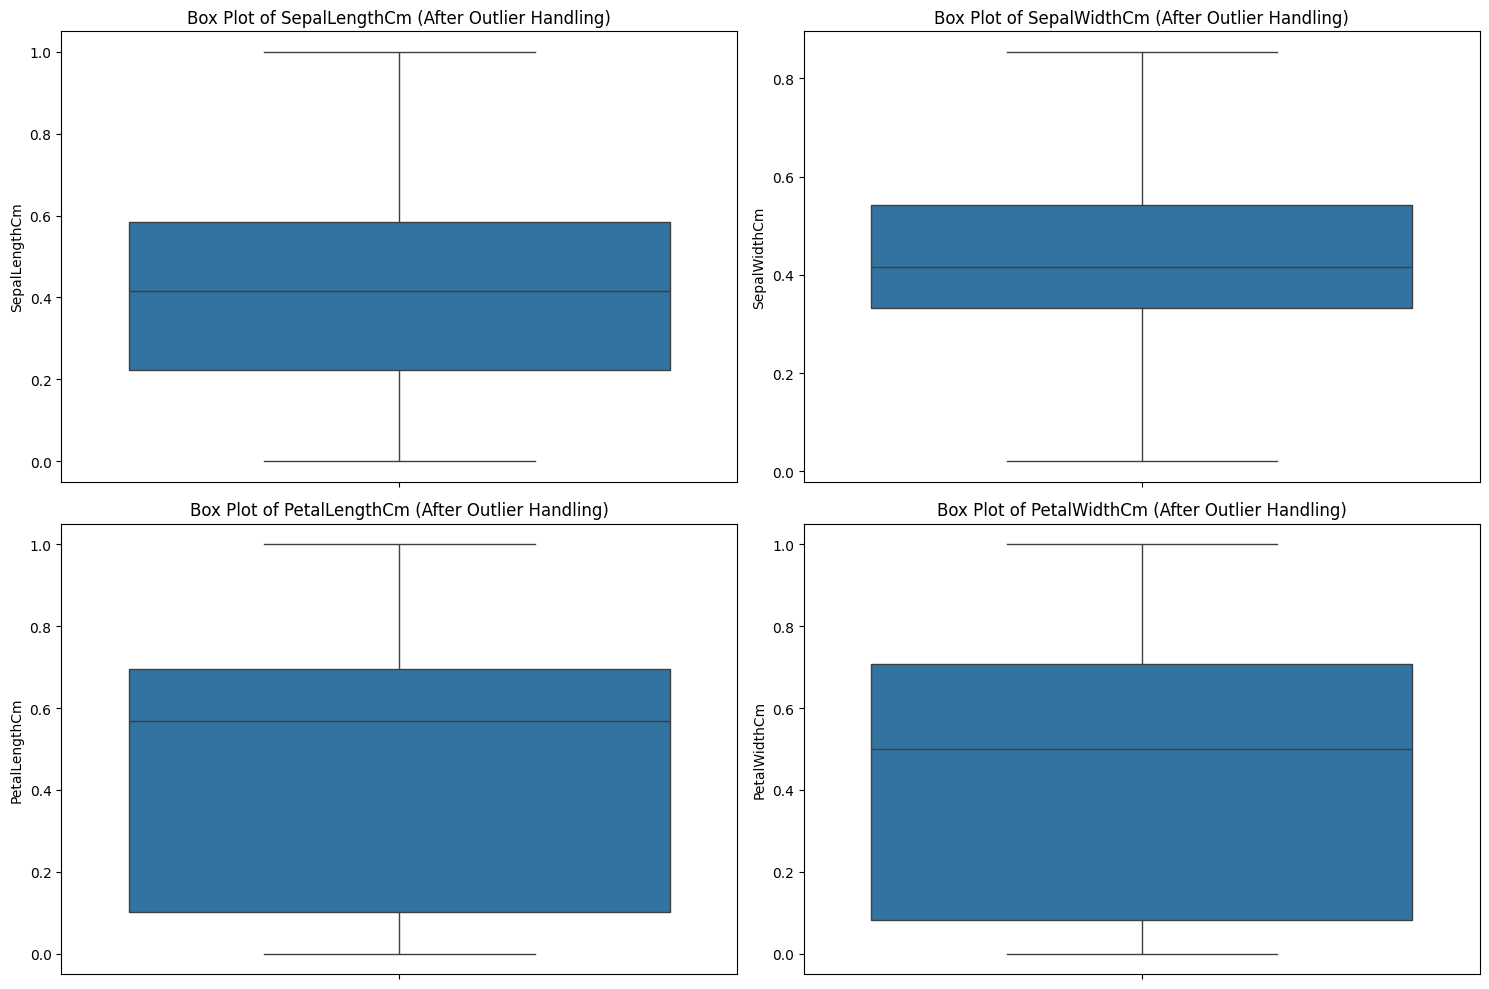

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature} (After Outlier Handling)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

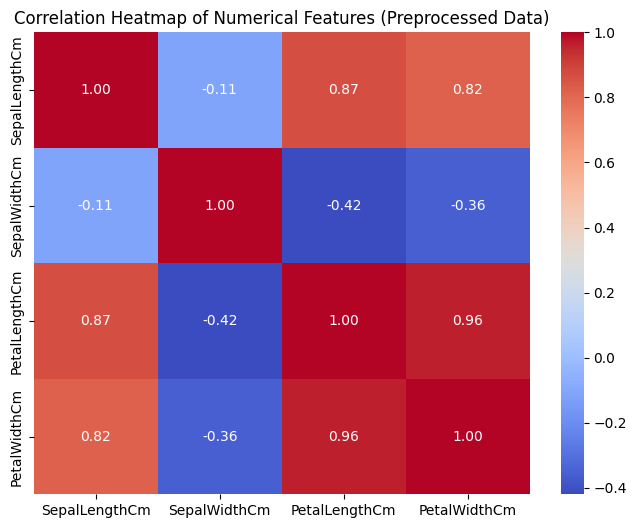

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
numerical_features_for_corr = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
correlation_matrix = df[numerical_features_for_corr].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features (Preprocessed Data)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print("\nFeatures (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Training set size: 105 samples
Test set size: 45 samples

Features (X) head:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0       0.222222      0.625000       0.067797      0.041667
1       0.166667      0.416667       0.067797      0.041667
2       0.111111      0.500000       0.050847      0.041667
3       0.083333      0.458333       0.084746      0.041667
4       0.194444      0.666667       0.067797      0.041667

Target (y) head:
0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64


In [ ]:
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_classifier.fit(X_train, y_train)
y_pred = dt_classifier.predict(X_test)
print("\nDecision Tree Classifier Performance (with max_depth=3):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Decision Tree Classifier Performance (with max_depth=3):
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [ ]:
print('Verification of X and y content and split sizes:')
print(f"X columns: {X.columns.tolist()}")
print(f"y target variable: {y.name}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("\nData is correctly prepared and split for hyperparameter tuning.")

Verification of X and y content and split sizes:
X columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
y target variable: Species
X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)

Data is correctly prepared and split for hyperparameter tuning.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train, y_train)
print("Grid Search Best Parameters:", grid_search.best_params_)
print("Grid Search Best Score (Accuracy):", grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Grid Search Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Grid Search Best Score (Accuracy): 0.9523809523809523


In [ ]:
best_dt_classifier = grid_search.best_estimator_
y_pred_tuned = best_dt_classifier.predict(X_test)
print("\nDecision Tree Classifier Performance (with Tuned Hyperparameters):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))


Decision Tree Classifier Performance (with Tuned Hyperparameters):
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint, uniform
param_distributions = {
    'max_depth': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}
random_search = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                                   param_distributions=param_distributions,
                                   n_iter=100,
                                   cv=5,
                                   scoring='accuracy',
                                   random_state=42,
                                   n_jobs=-1,
                                   verbose=1)
random_search.fit(X_train, y_train)
print("Random Search Best Parameters:", random_search.best_params_)
print("Random Search Best Score (Accuracy):", random_search.best_score_)
best_dt_classifier_rs = random_search.best_estimator_
y_pred_tuned_rs = best_dt_classifier_rs.predict(X_test)
print("\nDecision Tree Classifier Performance (with Tuned Hyperparameters from Randomized Search):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned_rs):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_rs))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_rs))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Random Search Best Parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 8}
Random Search Best Score (Accuracy): 0.9523809523809523

Decision Tree Classifier Performance (with Tuned Hyperparameters from Randomized Search):
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


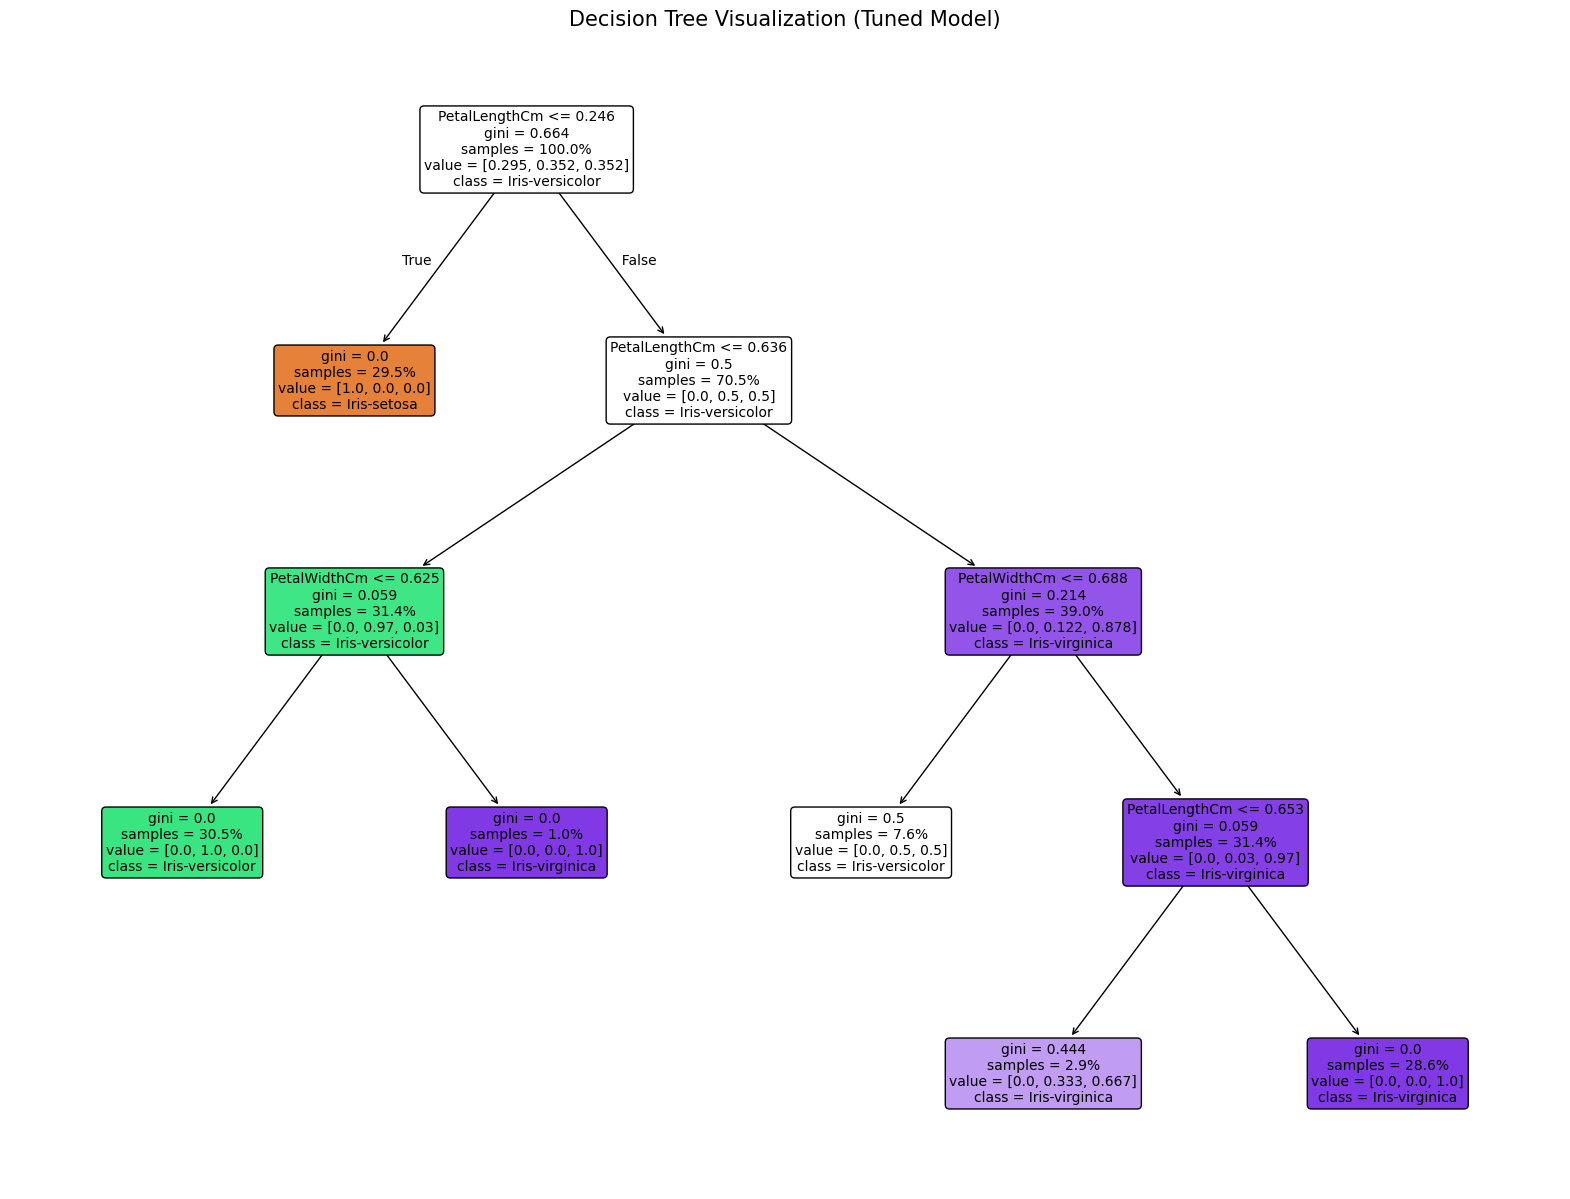

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plot_tree(best_dt_classifier,
          filled=True,
          feature_names=X_train.columns.tolist(),
          class_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
          rounded=True,
          proportion=True,
          fontsize=10)
plt.title('Decision Tree Visualization (Tuned Model)', fontsize=15)
plt.show()